In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, silhouette_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv('../data/processed/ecommerce_logs.csv', parse_dates=['event_time'])
df = df.drop_duplicates()

In [3]:
# 유저별 집계
user_features = (
    df.groupby(['user_id', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'click': 'click_count', 'purchase': 'purchase_count'})
)

# 파생 피처
user_features['conversion_rate'] = (
    user_features['purchase_count']
    / user_features['click_count'].replace(0, np.nan)
).fillna(0)

user_features['churn_flag'] = (
    (user_features['click_count'] > 0) & (user_features['purchase_count'] == 0)
).astype(int)

user_features['converted'] = (
    user_features['purchase_count'] > 0
).astype(int)

print(f'Feature Table Shape: {user_features.shape}')
user_features.head()

Feature Table Shape: (9553, 5)


event_type,click_count,purchase_count,conversion_rate,churn_flag,converted
user_id,,,,,
0002414f95344307404f0ace7a26f1d5,1,0,0.0,1,0
00072d033fe2e59061ae5c3aff1a2be5,1,0,0.0,1,0
000e943451fc2788ca6ac98a682f2f49,1,0,0.0,1,0
001a57041f56400917a187dd74e6cbc1,1,0,0.0,1,0
002905287304e28c0218389269b4759b,1,0,0.0,1,0


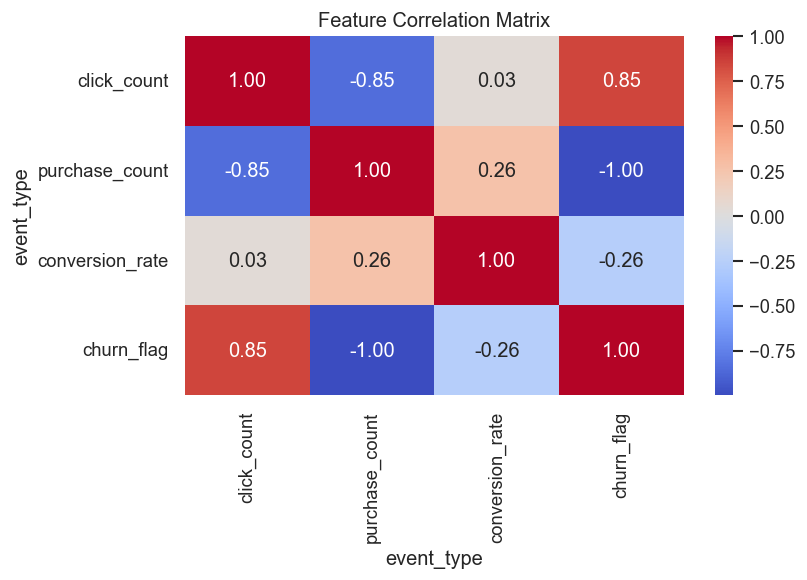

In [4]:
# 피처 상관관계
corr = user_features[['click_count', 'purchase_count', 'conversion_rate', 'churn_flag']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
# 이탈 예측 Logistic Regression

from sklearn.linear_model import LogisticRegression

X_churn = user_features[['click_count', 'purchase_count', 'conversion_rate']]
y_churn = user_features['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 스케일링 (Logistic Regression은 스케일에 민감)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model_churn = LogisticRegression(random_state=42, max_iter=1000)
model_churn.fit(X_train_s, y_train)
y_pred_churn = model_churn.predict(X_test_s)

print('Churn Prediction')
print(classification_report(y_test, y_pred_churn, target_names=['Active', 'Churn Risk']))


Churn Prediction
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       291
  Churn Risk       1.00      1.00      1.00      1620

    accuracy                           1.00      1911
   macro avg       1.00      1.00      1.00      1911
weighted avg       1.00      1.00      1.00      1911



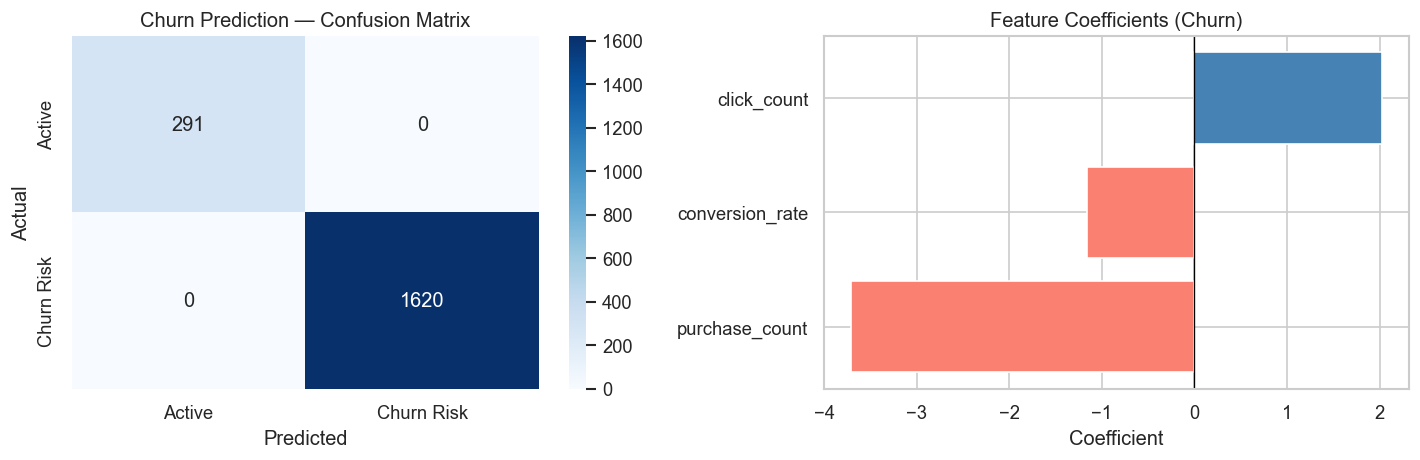

Cross-Validation F1: 1.0000 ± 0.0000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_churn)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Active', 'Churn Risk'],
    yticklabels=['Active', 'Churn Risk'],
    ax=axes[0]
)
axes[0].set_title('Churn Prediction — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 피처 계수
coef_df = pd.DataFrame({
    'Feature': X_churn.columns,
    'Coefficient': model_churn.coef_[0]
}).sort_values('Coefficient')

axes[1].barh(
    coef_df['Feature'], coef_df['Coefficient'],
    color=['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients (Churn)')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

# 교차검증
cv_scores = cross_val_score(model_churn, 
    scaler.fit_transform(X_churn), y_churn, cv=5, scoring='f1')
print(f'Cross-Validation F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

In [7]:
# 구매 전환 예측 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

X_cvr = user_features[['click_count', 'conversion_rate']]
y_cvr = user_features['converted']

X_train, X_test, y_train, y_test = train_test_split(
    X_cvr, y_cvr, test_size=0.2, random_state=42, stratify=y_cvr
)

model_cvr = RandomForestClassifier(n_estimators=100, random_state=42)
model_cvr.fit(X_train, y_train)
y_pred_cvr = model_cvr.predict(X_test)

print('=== Purchase Conversion Prediction ===')
print(classification_report(y_test, y_pred_cvr, target_names=['No Purchase', 'Purchase']))

=== Purchase Conversion Prediction ===
              precision    recall  f1-score   support

 No Purchase       1.00      1.00      1.00      1620
    Purchase       1.00      1.00      1.00       291

    accuracy                           1.00      1911
   macro avg       1.00      1.00      1.00      1911
weighted avg       1.00      1.00      1.00      1911



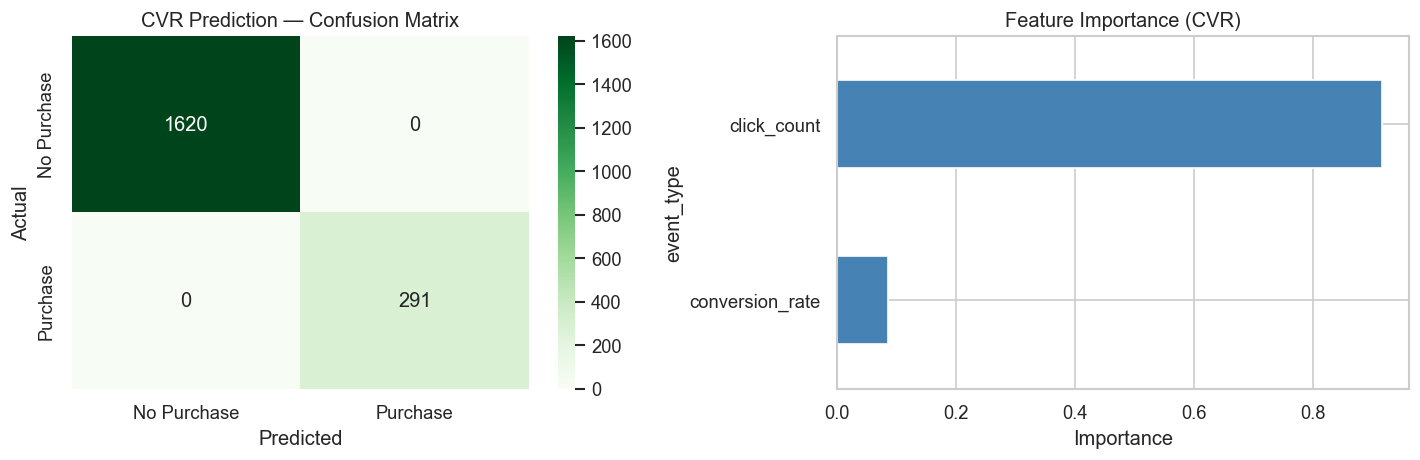

Cross-Validation F1: 1.0000 ± 0.0000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred_cvr)
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Greens',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase'],
    ax=axes[0]
)
axes[0].set_title('CVR Prediction — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance
importances = pd.Series(
    model_cvr.feature_importances_,
    index=X_cvr.columns
).sort_values()
importances.plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Feature Importance (CVR)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# 교차검증
cv_scores2 = cross_val_score(model_cvr, X_cvr, y_cvr, cv=5, scoring='f1')
print(f'Cross-Validation F1: {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}')

In [9]:
#  구매 수 예측 Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

X_reg = user_features[['click_count', 'conversion_rate']]
y_reg = user_features['purchase_count']

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_reg.fit(X_train, y_train)
y_pred_reg = model_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
mae  = np.mean(np.abs(y_test - y_pred_reg))
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')

RMSE: 0.0014
MAE:  0.0004


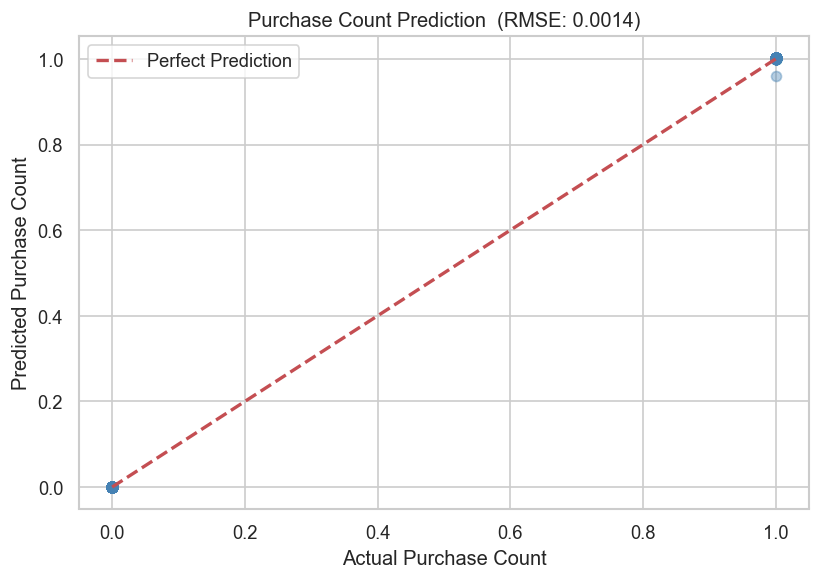

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Perfect Prediction'
)
plt.xlabel('Actual Purchase Count')
plt.ylabel('Predicted Purchase Count')
plt.title(f'Purchase Count Prediction  (RMSE: {rmse:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

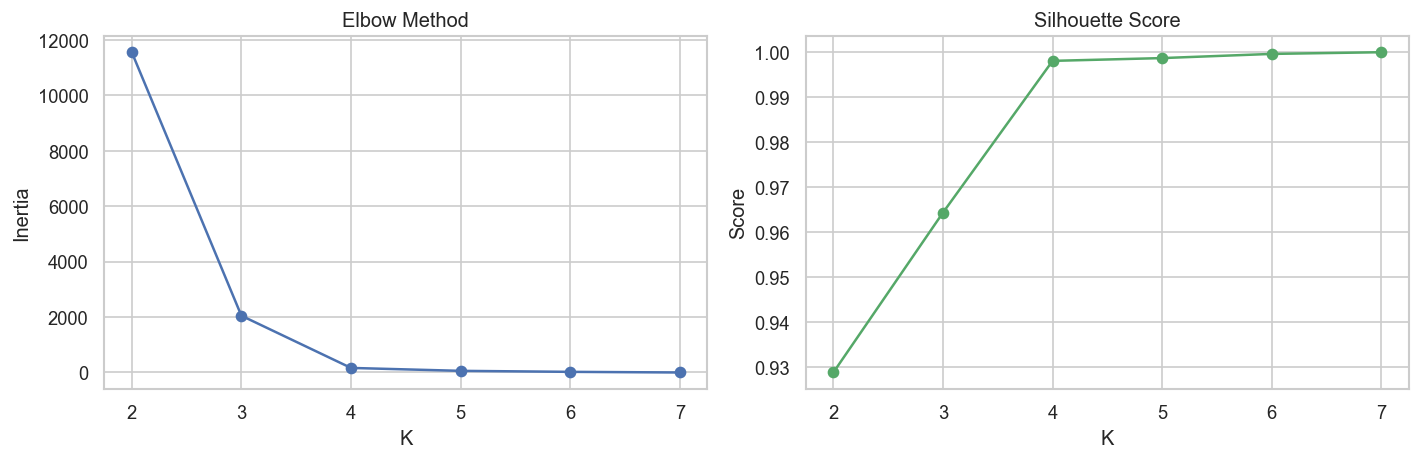

Best K: 3  (Silhouette Score: 0.9644)


In [16]:
# 유저 세그멘테이션 (K-Means)
from sklearn.cluster import KMeans

X_cluster = user_features[['click_count', 'purchase_count', 'conversion_rate']]

scaler2  = StandardScaler()
X_scaled = scaler2.fit_transform(X_cluster)

# 최적 K 탐색
inertias   = []
sil_scores = []
K_range    = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = 3
print(f'Best K: {best_k}  (Silhouette Score: {sil_scores[best_k - 2]:.4f})')

In [20]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

# 클러스터별 평균
cluster_summary = user_features.groupby('cluster')[[
    'click_count', 'purchase_count', 'conversion_rate'
]].mean().round(3)

# 라벨
cluster_summary['label'] = cluster_summary.apply(
    lambda row: 'High Value' if row['purchase_count'] >= 1.5
    else 'Churn Risk' if row['purchase_count'] < 0.5
    else 'Normal', axis=1
)

print('Cluster Summary')
print(cluster_summary)

Cluster Summary
event_type  click_count  purchase_count  conversion_rate       label
cluster                                                             
0                 1.039           0.000            0.000  Churn Risk
1                 0.000           1.002            0.000      Normal
2                 1.034           1.000            0.983      Normal


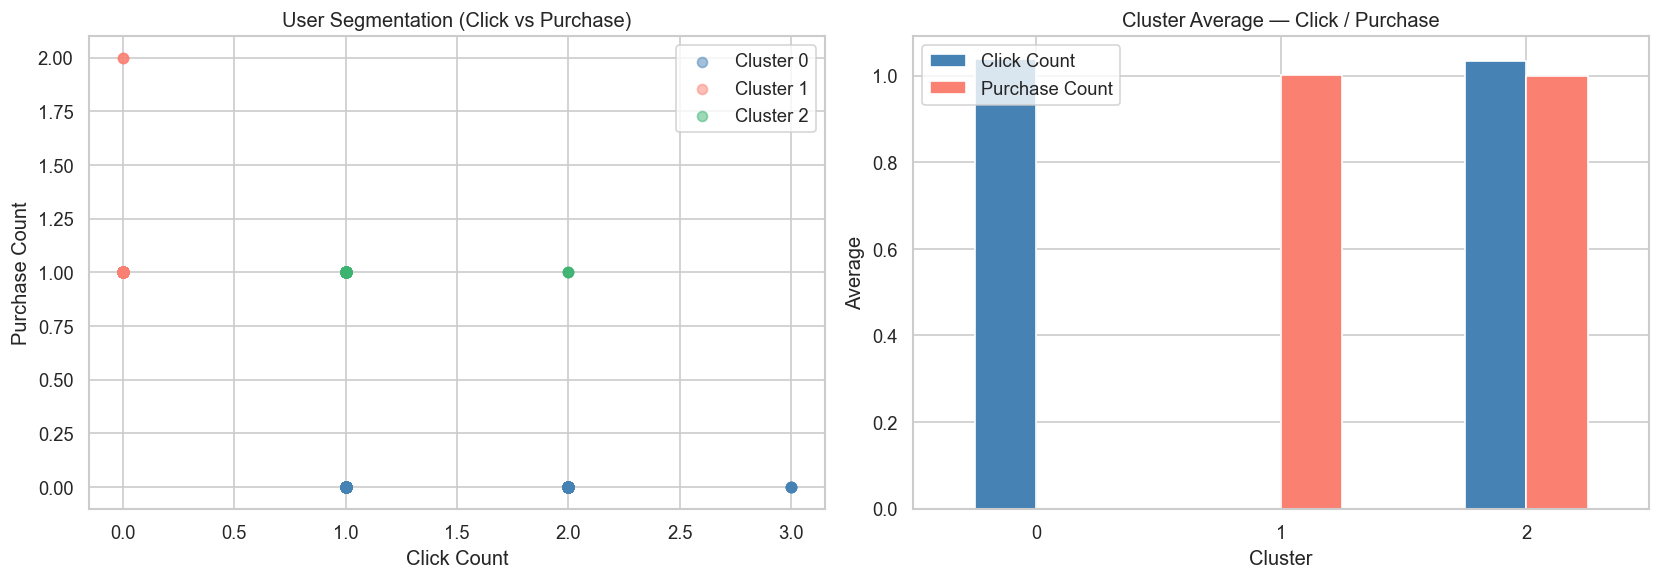

In [21]:
colors = ['steelblue', 'salmon', 'mediumseagreen', 'orange', 'purple', 'gold', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 클릭 vs 구매 산점도
for c in range(best_k):
    mask = user_features['cluster'] == c
    axes[0].scatter(
        user_features.loc[mask, 'click_count'],
        user_features.loc[mask, 'purchase_count'],
        label=f'Cluster {c}',
        alpha=0.5, color=colors[c]
    )
axes[0].set_xlabel('Click Count')
axes[0].set_ylabel('Purchase Count')
axes[0].set_title('User Segmentation (Click vs Purchase)')
axes[0].legend()

# 클러스터별 평균 막대그래프
cluster_summary[['click_count', 'purchase_count']].plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'salmon'],
    edgecolor='white'
)
axes[1].set_title('Cluster Average — Click / Purchase')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Average')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Click Count', 'Purchase Count'])

plt.tight_layout()
plt.show()

## ML 모델 성능 요약

| 모델 | 타겟 | 평가지표 | 비고 |
|------|------|----------|------|
| Logistic Regression | 이탈 예측 | F1 / CV F1 | 스케일링 적용 |
| Random Forest Classifier | 구매 전환 예측 | F1 / CV F1 | Feature Importance 확인 |
| Random Forest Regressor | 구매 수 예측 | RMSE / MAE | 실제 vs 예측 시각화 |
| K-Means | 유저 세그멘테이션 | Silhouette Score | Elbow + Silhouette로 최적 K 선정 |

### 비즈니스 활용 방안
- **이탈 위험 유저** → 쿠폰 / 리타겟팅 마케팅 집중 집행
- **전환 가능성 높은 유저** → 프리미엄 상품 노출 / 푸시 알림
- **클러스터별 맞춤 전략** → 세그먼트별 캠페인 설계
- **구매 수 예측** → 재고 관리 / 수요 예측에 활용